<a href="https://colab.research.google.com/github/RumanHasan0123/Simulation-ModelingLab/blob/main/Road_accident_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup: Import Libraries

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.stats import ttest_ind, chi2_contingency

## Setup: Mount Google Drive

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Loading

In [72]:
# Change the path according to your Drive folder
file_path = "/content/drive/MyDrive/Simulation_Project/dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Year,Number of Accidents,Death,Number of Serious Injuries,Number of Minor Injuries,Number of Moderate Injuries,Number of Severe Injuries
0,1980,1500,1300,1200,400,200,100
1,1981,1450,1250,1150,380,190,95
2,1982,1400,1200,1100,360,180,90
3,1983,1350,1150,1050,340,170,85
4,1984,1300,1100,1000,320,160,80


## Data Preprocessing: Check Shape and Nulls

**Data Preprocessing**

In [73]:
# ===== DATA PREPROCESSING =====

print("Dataset shape BEFORE cleaning:", df.shape)
print("\nChecking for missing (null) values...\n")

# Count null values per column
null_per_column = df.isnull().sum()

print("Null values in each column:")
print(null_per_column)

# Total null values in dataset
total_null = df.isnull().sum().sum()
print("\nTotal null values in dataset:", total_null)

Dataset shape BEFORE cleaning: (44, 7)

Checking for missing (null) values...

Null values in each column:
Year                           0
Number of Accidents            0
Death                          0
Number of Serious Injuries     0
Number of Minor Injuries       0
Number of Moderate Injuries    0
Number of Severe Injuries      0
dtype: int64

Total null values in dataset: 0


##Descriptive Statistics

In [74]:
print(df.describe())

              Year  Number of Accidents        Death  \
count    44.000000            44.000000    44.000000   
mean   2001.500000           772.727273   613.636364   
std      12.845233           358.688591   344.620390   
min    1980.000000           200.000000    50.000000   
25%    1990.750000           487.500000   337.500000   
50%    2001.500000           750.000000   600.000000   
75%    2012.250000          1012.500000   862.500000   
max    2023.000000          1500.000000  1300.000000   

       Number of Serious Injuries  Number of Minor Injuries  \
count                   44.000000                 44.000000   
mean                   518.750000                138.272727   
std                    337.015156                121.502486   
min                     25.000000                  2.000000   
25%                    237.500000                 17.500000   
50%                    500.000000                120.000000   
75%                    762.500000                225.0

## Data Exploration: Histogram of Number of Accidents

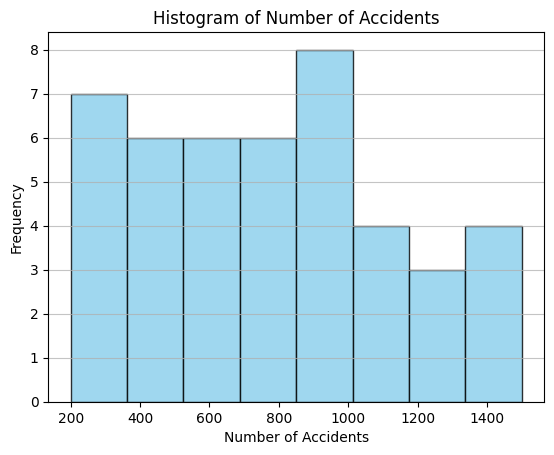

In [75]:
plt.hist(df['Number of Accidents'], bins=8, color='skyblue', edgecolor='black', alpha=0.8)
plt.title("Histogram of Number of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

## Data Exploration: Histogram of Deaths

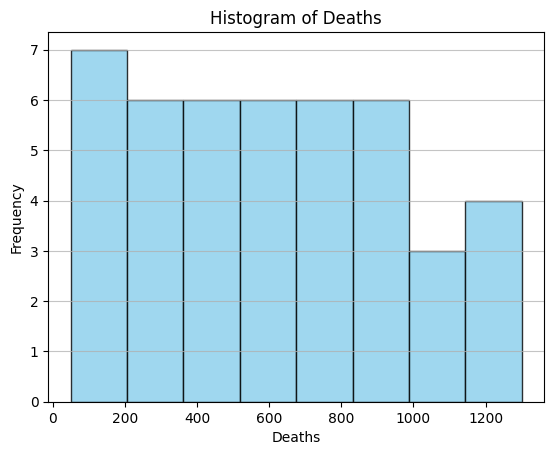

In [76]:
plt.hist(df['Death'], bins=8, color='skyblue', edgecolor='black', alpha=0.8)
plt.title("Histogram of Deaths")
plt.xlabel("Deaths")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

## Data Exploration: Histograms of Injury Types

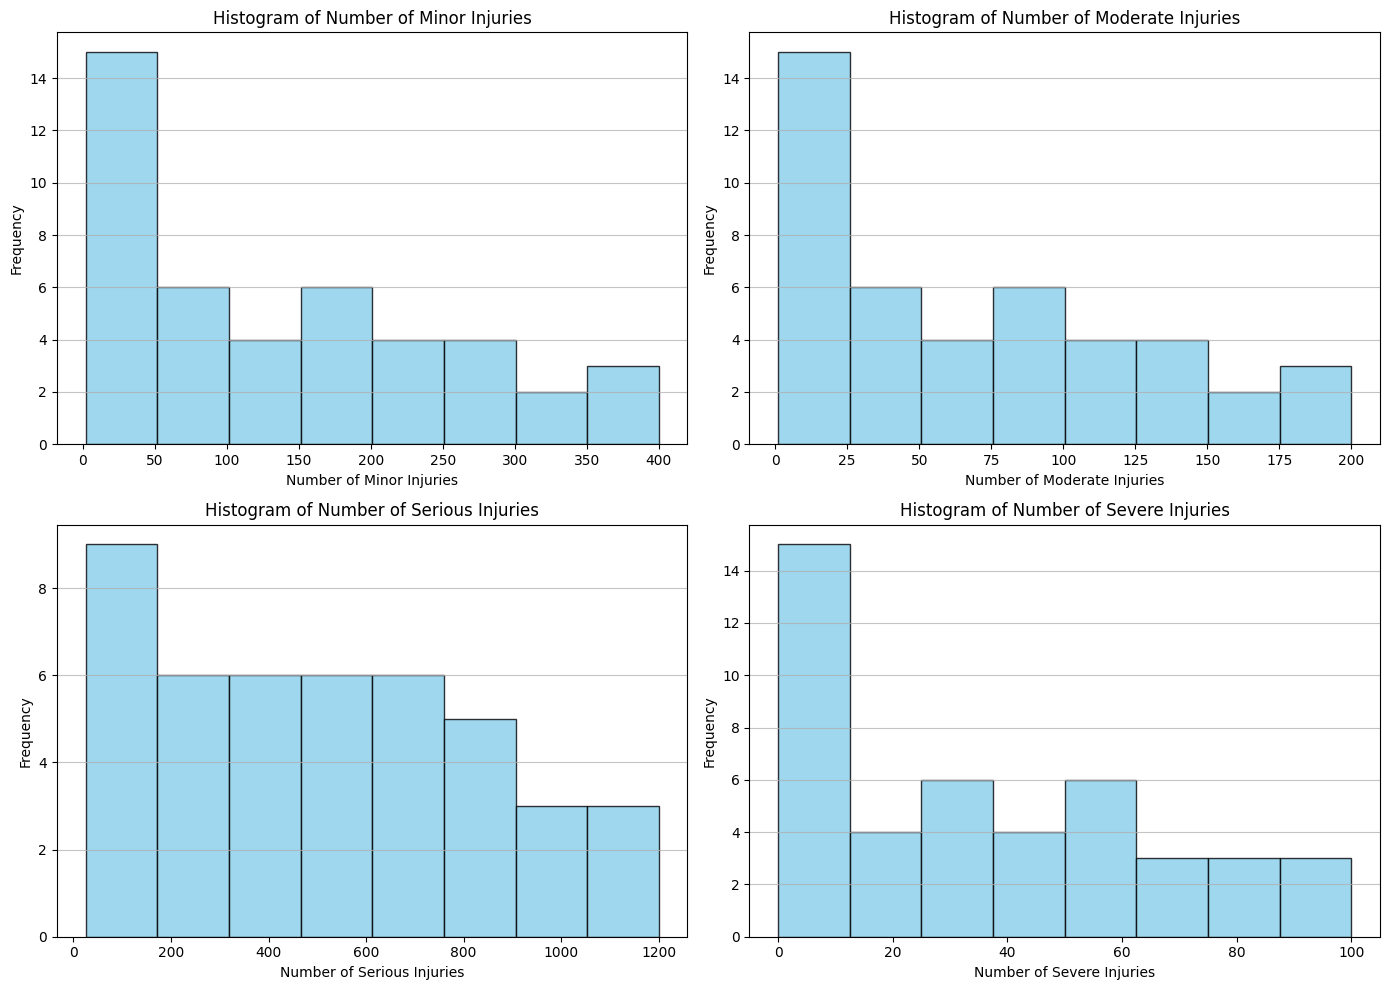

In [77]:
injury_columns = ['Number of Minor Injuries', 'Number of Moderate Injuries', 'Number of Serious Injuries', 'Number of Severe Injuries']

fig, axes = plt.subplots(2, 2, figsize=(14, 10)) # Create a 2x2 grid of subplots
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, col_name in enumerate(injury_columns):
    ax = axes[i]
    ax.hist(df[col_name], bins=8, color='skyblue', edgecolor='black', alpha=0.8)
    ax.set_title(f"Histogram of {col_name}")
    ax.set_xlabel(col_name)
    ax.set_ylabel("Frequency")
    ax.grid(axis='y', alpha=0.75)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Statistical Analysis: T-test for Accidents vs. 1200

In [78]:
t_stat, p = ttest_ind(df['Number of Accidents'], 1200)

print("p-value:", p)

if p < 0.05:
    print("Average accidents significantly different from 1200")
else:
    print("No significant difference")

p-value: 0.24531530943374136
No significant difference


## Statistical Analysis: T-test for Early vs. Recent Years

In [79]:
mid = len(df)//2
early_years = df.iloc[:mid]['Number of Accidents']
recent_years = df.iloc[mid:]['Number of Accidents']

t_stat, p = ttest_ind(early_years, recent_years)

print("p-value:", p)

if p < 0.05:
    print("Accidents changed over time")
else:
    print("No significant change")

p-value: 5.2829219830034884e-05
Accidents changed over time


## Statistical Analysis: Chi-squared Test for Injury Distribution

In [80]:
injury_totals = [
    df['Number of Minor Injuries'].sum(),
    df['Number of Moderate Injuries'].sum(),
    df['Number of Serious Injuries'].sum(),
    df['Number of Severe Injuries'].sum()
]

expected = [np.mean(injury_totals)]*4

chi2, p = chi2_contingency([injury_totals, expected])[:2]

print("p-value:", p)

if p < 0.05:
    print("Injury types are NOT equally distributed")
else:
    print("Injury types equally distributed")

p-value: 0.0
Injury types are NOT equally distributed


## Monte Carlo Simulation: Calculate Mean and Standard Deviation

In [81]:
mean_acc = df['Number of Accidents'].mean()
std_acc = df['Number of Accidents'].std()

print(mean_acc, std_acc)

772.7272727272727 358.6885909607556


## Monte Carlo Simulation: Generate Simulated Accidents

In [82]:
simulated_accidents = np.random.normal(mean_acc, std_acc, 20)
simulated_accidents = np.round(simulated_accidents)

## Monte Carlo Simulation: Visualize Real vs. Simulated Accident Data

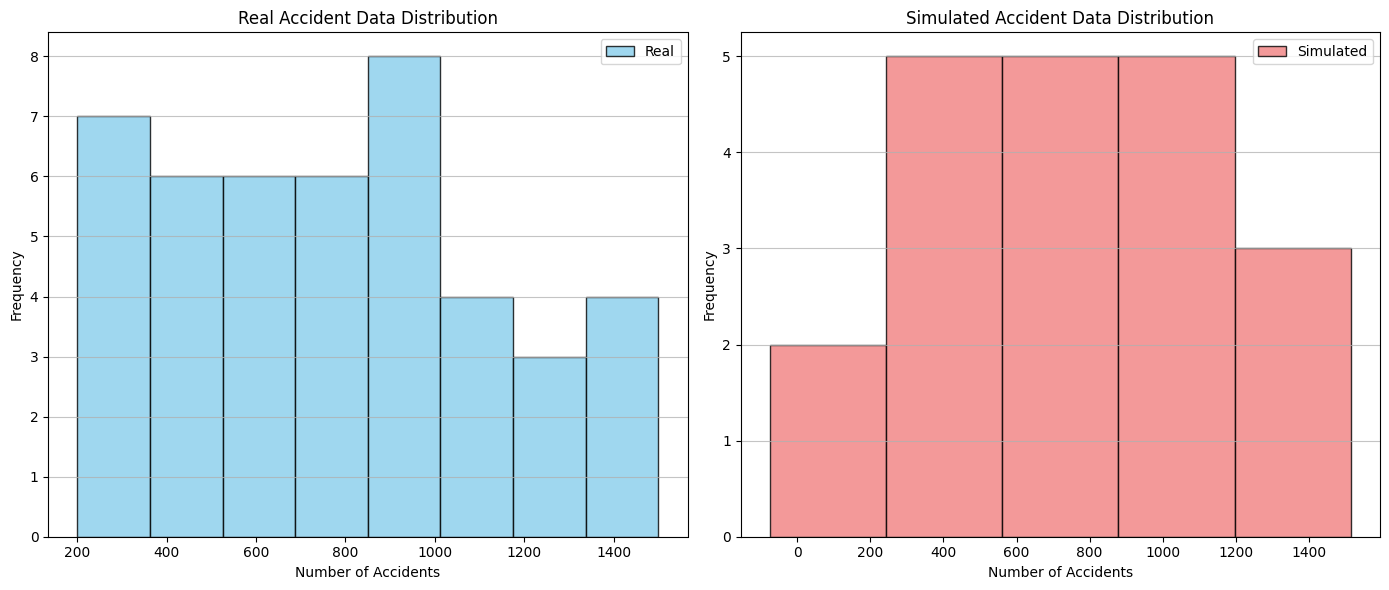

In [83]:
future_years = np.arange(df['Year'].max()+1, df['Year'].max()+21)

plt.figure(figsize=(14, 6)) # Slightly larger figure for better readability

# Subplot for Real data
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.hist(df['Number of Accidents'], bins=8, color='skyblue', edgecolor='black', alpha=0.8, label="Real")
plt.title("Real Accident Data Distribution")
plt.xlabel("Number of Accidents")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.75)

# Subplot for Simulated data
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
# Given only 20 simulated points, fewer bins might make it clearer.
plt.hist(simulated_accidents, bins=5, color='lightcoral', edgecolor='black', alpha=0.8, label="Simulated")
plt.title("Simulated Accident Data Distribution")
plt.xlabel("Number of Accidents")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.75)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Statistical Validation: T-test for Real vs. Simulated Data

In [84]:
t_stat, p = ttest_ind(df['Number of Accidents'], simulated_accidents)

print("p-value:", p)

if p > 0.05:
    print("Simulation matches real data")
else:
    print("Simulation differs from real data")

p-value: 0.7071503831795136
Simulation matches real data
